In [1]:
import zipfile

with zipfile.ZipFile("CMAPSSData.zip", "r") as zip_ref:
    zip_ref.extractall("CMAPSSData")

In [2]:
import os
print(os.listdir("CMAPSSData"))

['.ipynb_checkpoints', 'Damage Propagation Modeling.pdf', 'readme.txt', 'RUL_FD001.txt', 'RUL_FD002.txt', 'RUL_FD003.txt', 'RUL_FD004.txt', 'test_FD001.txt', 'test_FD002.txt', 'test_FD003.txt', 'test_FD004.txt', 'train_FD001.txt', 'train_FD002.txt', 'train_FD003.txt', 'train_FD004.txt']


In [3]:
import pandas as pd

columns = (
    ["engine_id", "cycle"]
    + ["setting_1", "setting_2", "setting_3"]
    + [f"sensor_{i}" for i in range(1, 22)]
)

train = pd.read_csv(
    "CMAPSSData/train_FD001.txt",
    sep=r"\s+",
    header=None,
    names=columns
)

train.head()

,engine_id,cycle,setting_1,setting_2,setting_3,sensor_1,sensor_2,sensor_3,sensor_4,sensor_5,...,sensor_12,sensor_13,sensor_14,sensor_15,sensor_16,sensor_17,sensor_18,sensor_19,sensor_20,sensor_21
0,1,1,-0.0007,-0.0004,100.0,518.67,641.82,1589.70,1400.60,14.62,...,521.66,2388.02,8138.62,8.4195,0.03,392,2388,100.0,39.06,23.4190
1,1,2,0.0019,-0.0003,100.0,518.67,642.15,1591.82,1403.14,14.62,...,522.28,2388.07,8131.49,8.4318,0.03,392,2388,100.0,39.00,23.4236
2,1,3,-0.0043,0.0003,100.0,518.67,642.35,1587.99,1404.20,14.62,...,522.42,2388.03,8133.23,8.4178,0.03,390,2388,100.0,38.95,23.3442
3,1,4,0.0007,0.0000,100.0,518.67,642.35,1582.79,1401.87,14.62,...,522.86,2388.08,8133.83,8.3682,0.03,392,2388,100.0,38.88,23.3739
4,1,5,-0.0019,-0.0002,100.0,518.67,642.37,1582.85,1406.22,14.62,...,522.19,2388.04,8133.80,8.4294,0.03,393,2388,100.0,38.90,23.4044


In [14]:
train.shape

(20631, 27)

In [15]:
train["RUL"] = (
    train.groupby("engine_id")["cycle"]
    .transform("max") - train["cycle"]
)

In [16]:
train[["engine_id", "cycle", "RUL"]].head(10)

,engine_id,cycle,RUL
0,1,1,191
1,1,2,190
2,1,3,189
3,1,4,188
4,1,5,187
5,1,6,186
6,1,7,185
7,1,8,184
8,1,9,183
9,1,10,182


In [17]:
train.info()

<class 'pandas.DataFrame'>
RangeIndex: 20631 entries, 0 to 20630
Data columns (total 27 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   engine_id  20631 non-null  int64  
 1   cycle      20631 non-null  int64  
 2   setting_1  20631 non-null  float64
 3   setting_2  20631 non-null  float64
 4   setting_3  20631 non-null  float64
 5   sensor_1   20631 non-null  float64
 6   sensor_2   20631 non-null  float64
 7   sensor_3   20631 non-null  float64
 8   sensor_4   20631 non-null  float64
 9   sensor_5   20631 non-null  float64
 10  sensor_6   20631 non-null  float64
 11  sensor_7   20631 non-null  float64
 12  sensor_8   20631 non-null  float64
 13  sensor_9   20631 non-null  float64
 14  sensor_10  20631 non-null  float64
 15  sensor_11  20631 non-null  float64
 16  sensor_12  20631 non-null  float64
 17  sensor_13  20631 non-null  float64
 18  sensor_14  20631 non-null  float64
 19  sensor_15  20631 non-null  float64
 20  sensor_16  20631 

In [18]:
train.isnull().sum().sum()

np.int64(0)

In [19]:
train.describe()

,engine_id,cycle,setting_1,setting_2,setting_3,sensor_1,sensor_2,sensor_3,sensor_4,sensor_5,...,sensor_13,sensor_14,sensor_15,sensor_16,sensor_17,sensor_18,sensor_19,sensor_20,sensor_21,RUL
count,20631.000000,20631.000000,20631.000000,20631.000000,20631.0,20631.00,20631.000000,20631.000000,20631.000000,2.063100e+04,...,20631.000000,20631.000000,20631.000000,2.063100e+04,20631.000000,20631.0,20631.0,20631.000000,20631.000000,20631.000000
mean,51.506568,108.807862,-0.000009,0.000002,100.0,518.67,642.680934,1590.523119,1408.933782,1.462000e+01,...,2388.096152,8143.752722,8.442146,3.000000e-02,393.210654,2388.0,100.0,38.816271,23.289705,107.807862
std,29.227633,68.880990,0.002187,0.000293,0.0,0.00,0.500053,6.131150,9.000605,5.329200e-15,...,0.071919,19.076176,0.037505,3.469531e-18,1.548763,0.0,0.0,0.180746,0.108251,68.880990
min,1.000000,1.000000,-0.008700,-0.000600,100.0,518.67,641.210000,1571.040000,1382.250000,1.462000e+01,...,2387.880000,8099.940000,8.324900,3.000000e-02,388.000000,2388.0,100.0,38.140000,22.894200,0.000000
25%,26.000000,52.000000,-0.001500,-0.000200,100.0,518.67,642.325000,1586.260000,1402.360000,1.462000e+01,...,2388.040000,8133.245000,8.414900,3.000000e-02,392.000000,2388.0,100.0,38.700000,23.221800,51.000000
50%,52.000000,104.000000,0.000000,0.000000,100.0,518.67,642.640000,1590.100000,1408.040000,1.462000e+01,...,2388.090000,8140.540000,8.438900,3.000000e-02,393.000000,2388.0,100.0,38.830000,23.297900,103.000000
75%,77.000000,156.000000,0.001500,0.000300,100.0,518.67,643.000000,1594.380000,1414.555000,1.462000e+01,...,2388.140000,8148.310000,8.465600,3.000000e-02,394.000000,2388.0,100.0,38.950000,23.366800,155.000000
max,100.000000,362.000000,0.008700,0.000600,100.0,518.67,644.530000,1616.910000,1441.490000,1.462000e+01,...,2388.560000,8293.720000,8.584800,3.000000e-02,400.000000,2388.0,100.0,39.430000,23.618400,361.000000


In [20]:
sensor_cols = [f"sensor_{i}" for i in range(1, 22)]

train[sensor_cols].nunique().sort_values()

sensor_1        1
sensor_5        1
sensor_16       1
sensor_10       1
sensor_19       1
sensor_18       1
sensor_6        2
sensor_17      13
sensor_8       53
sensor_13      56
sensor_20     120
sensor_11     159
sensor_2      310
sensor_12     427
sensor_7      513
sensor_15    1918
sensor_3     3012
sensor_4     4051
sensor_21    4745
sensor_14    6078
sensor_9     6403
dtype: int64

In [21]:
train.duplicated().sum()

np.int64(0)

In [22]:
train.groupby("engine_id")["cycle"].max()

engine_id
1      192
2      287
3      179
4      189
5      269
      ... 
96     336
97     202
98     156
99     185
100    200
Name: cycle, Length: 100, dtype: int64

## Engine Lifetime Distribution

#### The C-MAPSS FD001 training data contains complete engine trajectories.
#### For each engine, the maximum recorded cycle represents its observed lifetime.

In [27]:
engine_lifetime = train.groupby("engine_id")["cycle"].max()
engine_lifetime.head()

engine_id
1    192
2    287
3    179
4    189
5    269
Name: cycle, dtype: int64

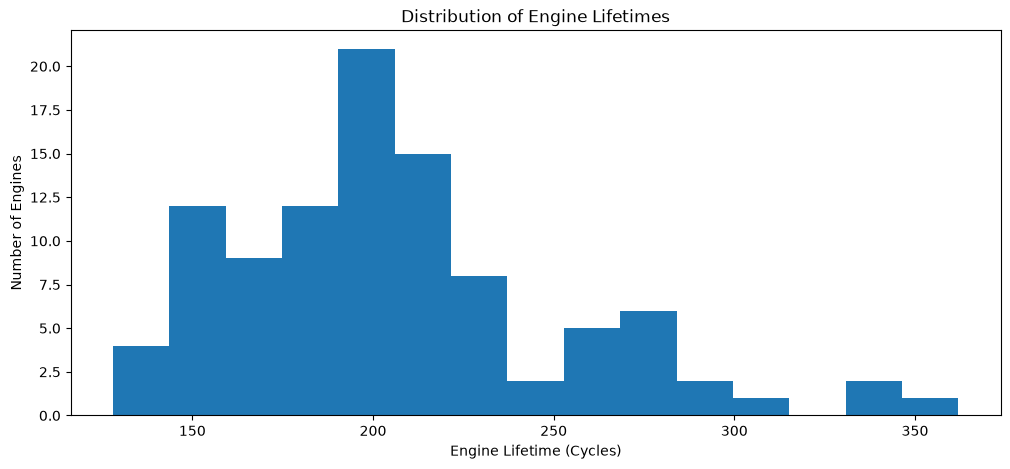

In [24]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 5))

plt.hist(engine_lifetime, bins=15)

plt.xlabel("Engine Lifetime (Cycles)")
plt.ylabel("Number of Engines")
plt.title("Distribution of Engine Lifetimes")

plt.show()

## Observation

#### The engine lifetimes vary considerably across the FD001 training dataset.Most engines have lifetimes concentrated in the middle of the observed range,while some engines operate for considerably fewer or more cycles.

#### This variation indicates that different engines experience degradation atdifferent rates, which is important for predictive maintenance modeling.

## RUL Distribution

#### RUL (Remaining Useful Life) represents the number of operating cycles remaining before an engine reaches the end of its observed life.

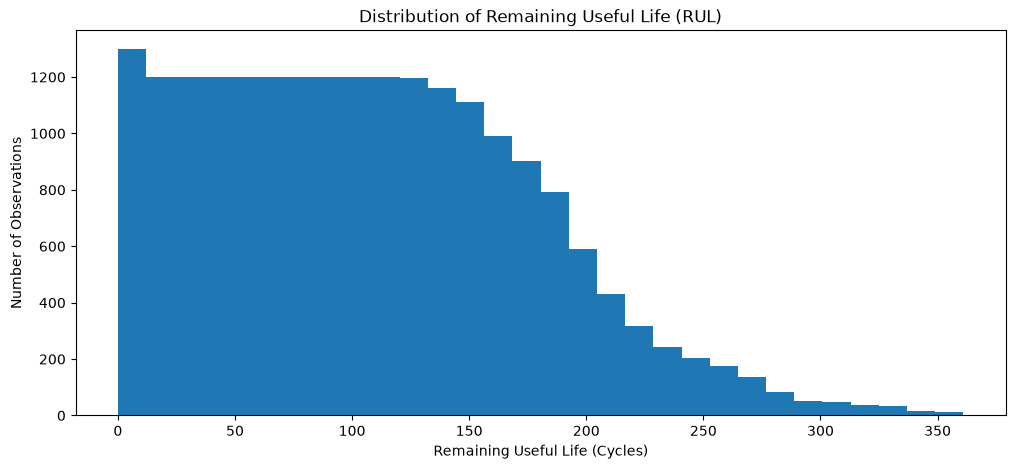

In [25]:
plt.figure(figsize=(12, 5))

plt.hist(train["RUL"], bins=30)

plt.xlabel("Remaining Useful Life (Cycles)")
plt.ylabel("Number of Observations")
plt.title("Distribution of Remaining Useful Life (RUL)")

plt.show()

## Observation

#### The RUL distribution is concentrated toward lower RUL values and gradually decreases as RUL increases.

#### This shows that observations close to the end of an engine's recorded life are relatively frequent in the training dataset.

#### RUL is the target variable that we will later use for regression modeling.

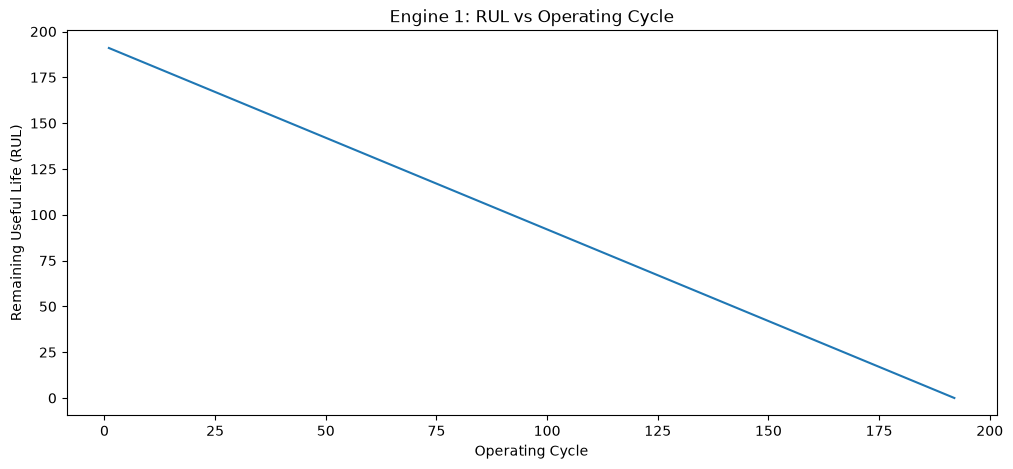

In [26]:
engine_1 = train[train["engine_id"] == 1]

plt.figure(figsize=(12, 5))

plt.plot(
    engine_1["cycle"],
    engine_1["RUL"]
)

plt.xlabel("Operating Cycle")
plt.ylabel("Remaining Useful Life (RUL)")
plt.title("Engine 1: RUL vs Operating Cycle")

plt.show()

## Observation

#### For Engine 1, RUL decreases linearly as the operating cycle increases.At the beginning of the engine's observed life, RUL is high, and it
#### gradually decreases to 0 at the final recorded cycle.

#### This visualization confirms the RUL calculation used for the training data.

## Sensor Variability

#### The number of unique values for each sensor is examined to identify constant and low-variation sensors.

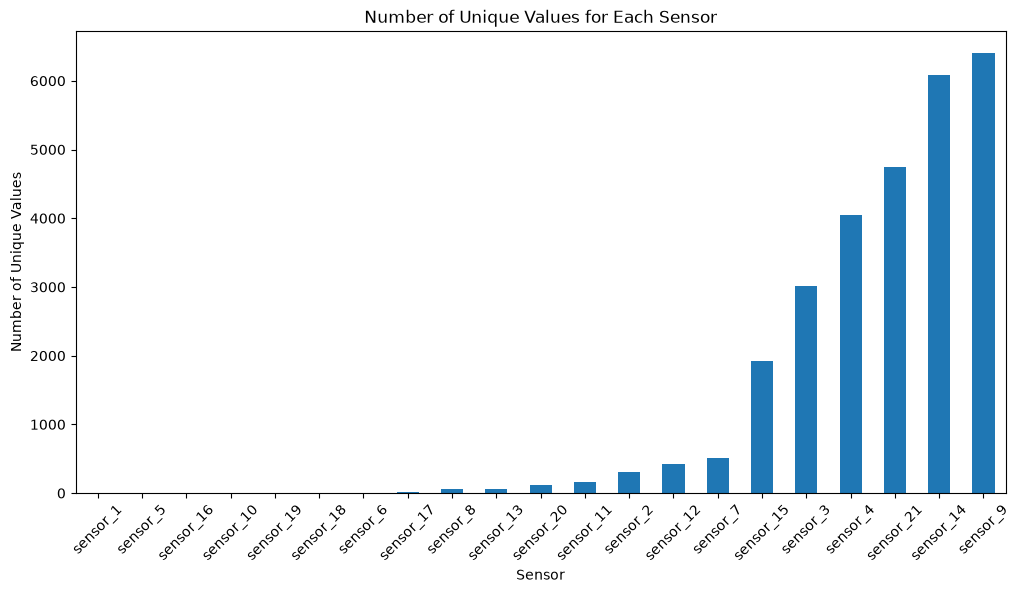

In [28]:
sensor_unique = train[sensor_cols].nunique()

plt.figure(figsize=(12, 6))

sensor_unique.sort_values().plot(kind="bar")

plt.xlabel("Sensor")
plt.ylabel("Number of Unique Values")
plt.title("Number of Unique Values for Each Sensor")
plt.xticks(rotation=45)

plt.show()

## Observation

#### The sensors show substantially different levels of variation.

#### Several sensors have only one unique value across the entire dataset, indicating that they are constant and provide no variation for learning
#### degradation patterns.

#### Other sensors have thousands of unique values, indicating much greater variation.

#### However, the number of unique values alone does not determine whether a sensor is useful for predicting RUL. Sensor degradation behavior and its
#### relationship with RUL will be investigated in the next stage.

## Engine 1: Sensor Behavior Over Operating Cycles

#### We examine how an individual sensor changes as the engine operates through successive cycles.

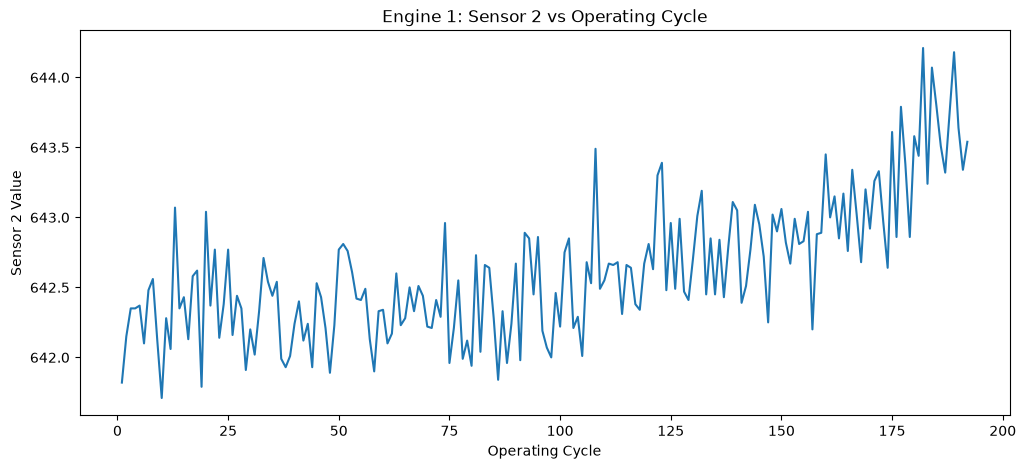

In [29]:
engine_1 = train[train["engine_id"] == 1]

plt.figure(figsize=(12, 5))

plt.plot(
    engine_1["cycle"],
    engine_1["sensor_2"]
)

plt.xlabel("Operating Cycle")
plt.ylabel("Sensor 2 Value")
plt.title("Engine 1: Sensor 2 vs Operating Cycle")

plt.show()

## Observation

#### Sensor 2 shows noticeable variation across the operating cycles of Engine 1.The measurements fluctuate from cycle to cycle, indicating noise in the sensor signal.

#### A gradual change in the sensor values can also be observed toward the later cycles. This suggests that Sensor 2 may contain information related to engine degradation, although the relationship needs to be investigated more carefully using additional engines and analysis techniques.

## Correlation Heatmap

#### A correlation heatmap is used to visualize the linear relationships between the numerical variables in the dataset, including the relationship between sensor measurements and RUL.

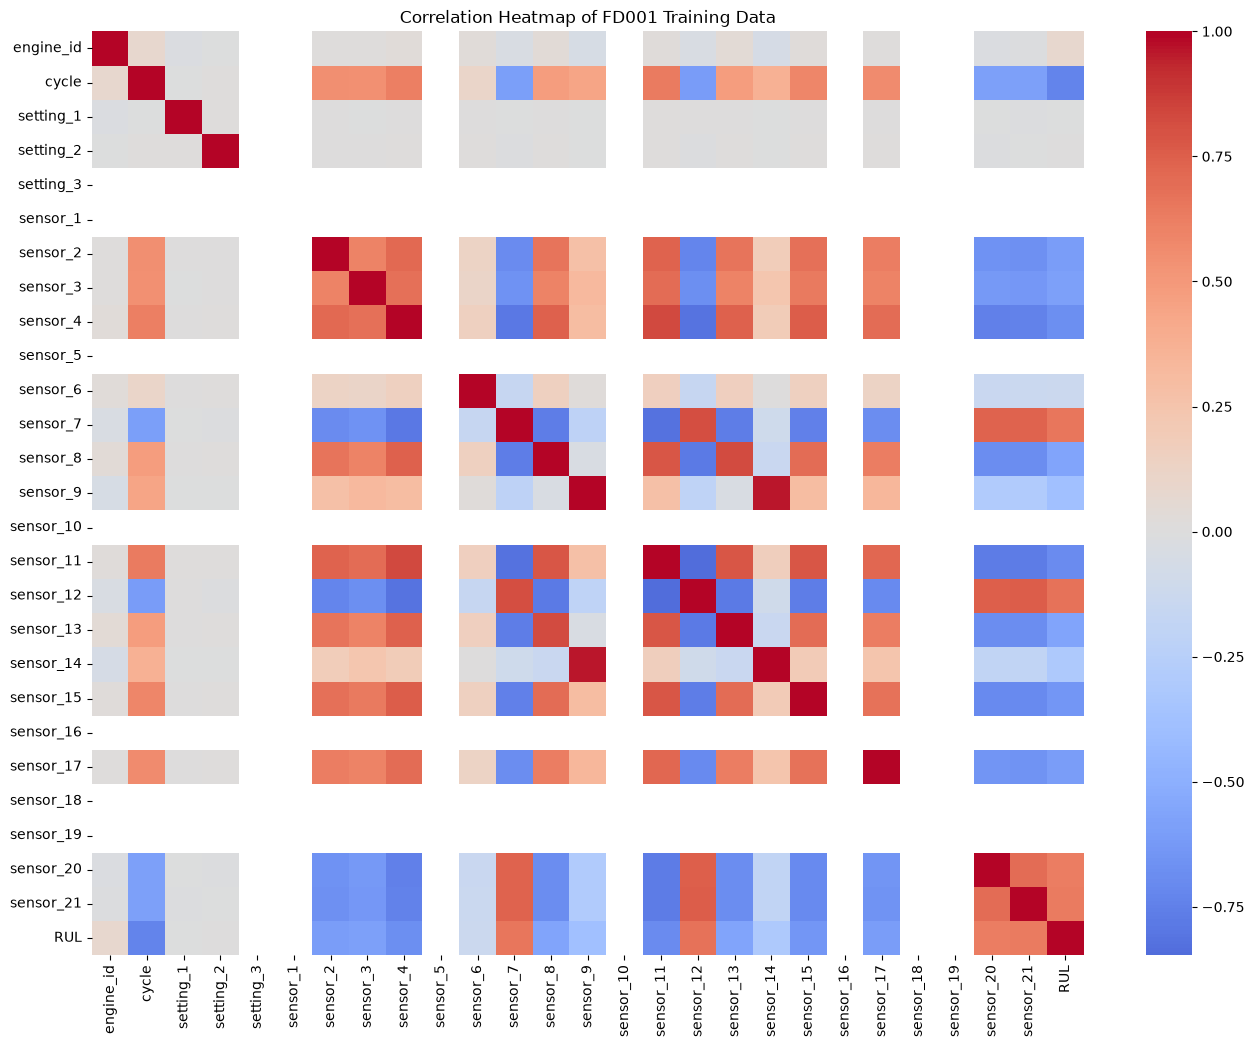

In [30]:
import seaborn as sns
import matplotlib.pyplot as plt

corr = train.corr(numeric_only=True)

plt.figure(figsize=(16, 12))

sns.heatmap(
    corr,
    cmap="coolwarm",
    center=0
)

plt.title("Correlation Heatmap of FD001 Training Data")

plt.show()

### Observation

#### The correlation heatmap provides an overall view of the linear relationships between the numerical variables in the FD001 training dataset.

#### Several sensors show different levels and directions of correlation with other variables, including RUL.

#### The constant sensors appear without meaningful correlation values because their values do not vary across the dataset. Therefore, correlation cannot be
#### calculated for these sensors.

#### Correlation provides an initial understanding of relationships, but it alone is not sufficient for selecting the final features for the machine learning models.

# Final EDA Summary

## Key Findings

- The FD001 training dataset contains 20,631 observations and 26 original columns.
- RUL was calculated for each engine using its maximum recorded cycle.
- After adding RUL, the dataset contains 27 columns.
- No missing values were found in the training dataset.
- Duplicate rows were checked as part of the data-quality analysis.
- Engine lifetimes vary considerably across different engines.
- Several sensors are constant and therefore provide no variation.
- Other sensors show substantial variation across operating cycles.
- Sensor 2 shows noticeable fluctuations and a possible change in behavior as Engine 1 progresses through its operating cycles.
- The correlation heatmap provides an initial view of relationships between sensors, operating variables, cycle, and RUL.
- Correlation and number of unique values alone are not sufficient to determine the final sensor features.

## Conclusion

The initial exploratory analysis provides an understanding of the structure, quality, target variable, engine lifetimes, and sensor behavior in the FD001 dataset.

The next stage is to investigate sensor degradation patterns more carefully across engines and identify sensors that contain useful information about
engine degradation and Remaining Useful Life.